# 2.5 Optimal Trading Strategy

In this notebook, we convert the synthetic alpha signals from Section 2.4 into actual trade schedules.

The previous sections provide:

$$
\text{prices},\quad
\text{fitted impact parameters},\quad
\text{backtest engine},\quad
\text{synthetic alpha level and decay}.
$$

The goal here is to produce trade panels

$$
q_{i,d,j},
$$

where $i$ is the stock, $d$ is the date, and $j$ is the intraday time bin. Positive trades are buys and negative trades are sells.

The strategy is based on the OW target-impact rule from the lecture notes. The lecture defines the alpha level and its drift as

$$
\alpha_t = \mathbb{E}[S_T - S_t \mid \mathcal{F}_t],
\qquad
 d\alpha_t = \mu_t dt + \sigma_t dW_t.
$$

The alpha decay used in Section 2.4 is

$$
\text{decay}_t = -\mu_t.
$$

For the simple OW case with constant liquidity, the optimal target impact is

$$
I_t^*
=
\frac{1}{2}
\left(
\alpha_t - \frac{\mu_t}{\beta}
\right)
=
\frac{1}{2}
\left(
\alpha_t + \frac{\text{decay}_t}{\beta}
\right).
$$

The fitted OW model in the previous notebook is implemented as

$$
F_{i,d,j}
=
e^{-\beta_i\Delta t}F_{i,d,j-1}
+
\sigma_i\frac{q_{i,d,j}}{ADV_i},
\qquad
I_{i,d,j}=\lambda_i F_{i,d,j}.
$$

So, after computing the target impact $I^*$, trades are recovered from

$$
q_{i,d,j}
=
\frac{ADV_i}{\lambda_i\sigma_i}
\left(
I^*_{i,d,j}
-
e^{-\beta_i\Delta t}I^*_{i,d,j-1}
\right),
\qquad I^*_{i,d,-1}=0.
$$

The core flow is therefore:

$$
(\alpha,\text{decay})
\longrightarrow
I^*
\longrightarrow
q.
$$

In this version we do **not** normalize the OW strategy to a fixed daily participation rate. We use the raw OW trades implied by the fitted OW model and the synthetic alpha signals. TWAP is kept only as a simple benchmark.

## 1. Imports and paths

This notebook assumes that the helper `.py` files and the saved results from Sections 2.1--2.4 are available in the same folder as this notebook.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import src.data_prep as data_prep
import src.backtest_engine as backtest_engine
import src.optimal_trading_strategies as optimal_trading_strategies

DATA_DIR = r"data"

sys.path.append(str(DATA_DIR))

from src.data_prep import *
from src.backtest_engine import *
from src.optimal_trading_strategies import *

## 2. Load outputs from previous sections

This section imports the objects created in Sections 2.1--2.4.

From Section 2.1:

- `test_px_df`: observed test-period mid-prices $P_{i,d,j}$;
- `test_traded_volume_df`: public market traded volume $\Delta Q^{mkt}_{i,d,j}$;
- `scaling_df`: stock-level $ADV_i$ and $\sigma_i$.

From Section 2.2:

- `stock_results_df`: fitted stock-level impact results across model types and half-lives;
- `best_df`: selected best half-life for each model type.

From Section 2.4:

- `synthetic_alpha_df`: synthetic intraday alpha level $\alpha_{i,d,j}$;
- `synthetic_alpha_decay_df`: synthetic alpha decay $-\mu_{i,d,j}$;
- `synthetic_alpha_diagnostics_df`: alpha-construction diagnostics.

All stock-date-time panels must have the same index and intraday columns.

In [2]:
# Section 2.1 outputs: price and traded-volume panels.
train_px_df = load_panel_csv(os.path.join(DATA_DIR, "train_px_201901_20.csv"))
test_px_df = load_panel_csv(os.path.join(DATA_DIR, "test_px_201902_20.csv"))
test_traded_volume_df = load_panel_csv(os.path.join(DATA_DIR, "test_traded_volume_201902_20.csv"))

# Section 2.1 output: stock-level scaling variables.
scaling_df = load_stock_level_csv(os.path.join(DATA_DIR, "scaling_201901_20.csv"))

# Section 2.2 outputs: fitted impact model parameters.
best_df = pd.read_csv(
    os.path.join(DATA_DIR, "impact_model_best_by_is_201901_train_201902_test.csv")
)

stock_results_df = pd.read_csv(
    os.path.join(DATA_DIR, "impact_model_stock_results_201901_train_201902_test.csv")
)

# Section 2.4 outputs: synthetic alpha level and diagnostics.
synthetic_alpha_df = load_panel_csv(
    os.path.join(DATA_DIR, "synthetic_alpha_201902_20.csv")
)

synthetic_alpha_diagnostics_df = load_stock_level_csv(
    os.path.join(DATA_DIR, "synthetic_alpha_diagnostics_201902_20.csv")
)

# Section 2.4 output: synthetic alpha decay.
# Prefer the saved Section 2.4 decay panel if it exists. If the old file set
# does not contain it, reconstruct the same lecture convention here:
#     decay_t = -mu_t = -(alpha_{t+dt} - alpha_t) / dt.
synthetic_alpha_decay_path = os.path.join(DATA_DIR, "synthetic_alpha_decay_201902_20.csv")

if os.path.exists(synthetic_alpha_decay_path):
    synthetic_alpha_decay_df = load_panel_csv(synthetic_alpha_decay_path)
else:
    synthetic_alpha_decay_df = make_alpha_decay_df_from_alpha(
        synthetic_alpha_df,
        dt_seconds=10,
    )

# Keep only common intraday columns across all panel objects.
# This is needed because the strategy computes trades time-bin by time-bin.
test_px_df, test_traded_volume_df, synthetic_alpha_df, synthetic_alpha_decay_df = align_intraday_columns(
    test_px_df,
    test_traded_volume_df,
    synthetic_alpha_df,
    synthetic_alpha_decay_df,
)

# Basic shape checks.
print("train_px_df:", train_px_df.shape)
print("test_px_df:", test_px_df.shape)
print("test_traded_volume_df:", test_traded_volume_df.shape)
print("synthetic_alpha_df:", synthetic_alpha_df.shape)
print("synthetic_alpha_decay_df:", synthetic_alpha_decay_df.shape)
print("synthetic_alpha_diagnostics_df:", synthetic_alpha_diagnostics_df.shape)
print("scaling_df:", scaling_df.shape)
print("best_df:", best_df.shape)
print("stock_results_df:", stock_results_df.shape)

# These panels must now have the same shape.
assert test_px_df.shape == test_traded_volume_df.shape
assert test_px_df.shape == synthetic_alpha_df.shape
assert test_px_df.shape == synthetic_alpha_decay_df.shape
assert test_px_df.columns.equals(test_traded_volume_df.columns)
assert test_px_df.columns.equals(synthetic_alpha_df.columns)
assert test_px_df.columns.equals(synthetic_alpha_decay_df.columns)

c:\Users\rapha\OneDrive\Imperial\Quant Trading\src\optimal_trading_strategies.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  alpha_df.shift(-1, axis=1)


train_px_df: (420, 2341)
test_px_df: (380, 2341)
test_traded_volume_df: (380, 2341)
synthetic_alpha_df: (380, 2341)
synthetic_alpha_decay_df: (380, 2341)
synthetic_alpha_diagnostics_df: (20, 8)
scaling_df: (20, 2)
best_df: (3, 9)
stock_results_df: (420, 25)


## 3. Reconstruct fitted model parameter tables

Section 2.2 fitted each model over a grid of half-lives. Here we select, for each model type, the stock-level rows corresponding to the best half-life chosen in Section 2.2.

For Section 2.5, the important parameters are

$$
\lambda_i
\quad \text{and} \quad
H_i.
$$

The OW fitted table is used to generate the OW target-impact trade schedules. The AFS and reduced-form fitted tables are only used later for optional robustness backtests.

In [3]:
model_types = ["ow", "afs", "reduced_form"]

required_cols = ["lambda_hat", "half_life_seconds", "is_r2", "oos_r2"]

fit_dfs = {}
fit_summary_rows = []

test_stocks = set(test_px_df.index.get_level_values(0).unique())

for model_type in model_types:
    fit_df = get_best_model_fit_df(
        stock_results_df=stock_results_df,
        best_df=best_df,
        model_type=model_type,
    )

    missing_cols = [col for col in required_cols if col not in fit_df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"{model_type} fit_df is missing columns: {missing_cols}")

    fit_dfs[model_type] = fit_df

    selected_half_life_seconds = fit_df["half_life_seconds"].iloc[0]
    selected_half_life_minutes = selected_half_life_seconds / 60

    missing_stocks = sorted(test_stocks - set(fit_df.index))

    fit_summary_rows.append({
        "model_type": model_type,
        "n_stocks": fit_df.shape[0],
        "selected_half_life_minutes": selected_half_life_minutes,
        "mean_is_r2": fit_df["is_r2"].mean(),
        "mean_oos_r2": fit_df["oos_r2"].mean(),
        "n_missing_test_stocks": len(missing_stocks),
    })

fit_summary_df = pd.DataFrame(fit_summary_rows)

display(fit_summary_df)

for model_type, fit_df in fit_dfs.items():
    print(model_type)
    display(fit_df[required_cols].head())

,model_type,n_stocks,selected_half_life_minutes,mean_is_r2,mean_oos_r2,n_missing_test_stocks
0,ow,20,30.0,0.167120,0.158372,0
1,afs,20,5.0,0.153022,0.149694,0
2,reduced_form,20,10.0,0.196336,0.179360,0


ow


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,262.866026,1800,0.143934,0.199819
AAPL,407.392206,1800,0.231705,0.252164
ABBV,382.822089,1800,0.130716,0.131900
ABT,440.867448,1800,0.171972,0.115936
ADBE,339.189338,1800,0.123732,0.137870


afs


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,0.770608,300,0.151269,0.185629
AAPL,0.828313,300,0.234038,0.227081
ABBV,0.540337,300,0.102414,0.115905
ABT,0.550386,300,0.133748,0.099200
ADBE,0.573366,300,0.130973,0.123505


reduced_form


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,73.752339,600,0.181003,0.244088
AAPL,106.653594,600,0.281354,0.309429
ABBV,89.711831,600,0.151770,0.123431
ABT,99.691282,600,0.186580,0.098858
ADBE,87.620862,600,0.156239,0.175975


## 4. Strategy containers and global settings

We keep the strategy outputs in dictionaries. This makes it clear which trade panel belongs to which strategy.

For the OW alpha strategy, we now use the **raw closed-form OW trades**. We do not rescale daily absolute volume to a fixed participation rate. This is important because rescaling would change the magnitude of the analytical OW optimum.

The decay signal is a finite-difference object, so it is much noisier than the alpha level. We therefore use optional rolling smoothing before computing the target impact:

- mild or no smoothing for the alpha level;
- stronger smoothing for alpha decay.

In [4]:
dt_seconds = 10

# Optional stabilisation of the alpha inputs before applying the OW formula.
smooth_alpha_window = None
smooth_decay_window = 10

# Optional risk controls for the raw OW strategy. Keep them as None for the
# unconstrained raw OW formula.
target_impact_cap = None
max_trade_fraction_adv_per_bin = None
force_zero_close = False

# TWAP benchmark only. This is not used to rescale the OW strategy.
twap_total_abs_participation = 0.20

ow_fit_df = fit_dfs["ow"]

alpha_scenarios = {} # stores raw alpha signals
alpha_decay_scenarios = {} # stores alpha decay signals, decay = -mu_t
strategy_trade_dfs = {} # stores actual trades q_t used in backtest
target_impact_dfs = {} # stores I*_t from OW formula
used_alpha_dfs = {} # stores alpha after optional smoothing
used_alpha_decay_dfs = {} # stores decay after optional smoothing
strategy_diagnostic_dfs = {} # stores raw OW strategy diagnostics

## 5. Baseline alpha scenario: intraday alpha and alpha decay

We first run the strategy using the synthetic intraday alpha level and the synthetic alpha decay from Section 2.4.

The core pipeline is:

$$
\left(\alpha_{i,d,j},\; \text{decay}_{i,d,j}\right)
\longrightarrow
I^*_{i,d,j}
\longrightarrow
q_{i,d,j}.
$$

Here

$$
\text{decay}_{i,d,j} = -\mu_{i,d,j}.
$$

In [5]:
alpha_scenarios["intraday_only"] = synthetic_alpha_df.copy()
alpha_decay_scenarios["intraday_only"] = synthetic_alpha_decay_df.copy()

(
    trades_df,
    target_impact_df,
    used_alpha_df,
    used_alpha_decay_df,
    strategy_diagnostics_df,
) = make_ow_optimal_trade_df(
    alpha_df=alpha_scenarios["intraday_only"],
    alpha_decay_df=alpha_decay_scenarios["intraday_only"],
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    dt_seconds=dt_seconds,
    smooth_alpha_window=smooth_alpha_window,
    smooth_decay_window=smooth_decay_window,
    target_impact_cap=target_impact_cap,
    max_trade_fraction_adv_per_bin=max_trade_fraction_adv_per_bin,
    force_zero_close=force_zero_close,
)

strategy_trade_dfs["intraday_only"] = trades_df
target_impact_dfs["intraday_only"] = target_impact_df
used_alpha_dfs["intraday_only"] = used_alpha_df
used_alpha_decay_dfs["intraday_only"] = used_alpha_decay_df
strategy_diagnostic_dfs["intraday_only"] = strategy_diagnostics_df

print("intraday_only raw OW strategy")
print("  total abs traded:", trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  max abs target impact:", target_impact_df.abs().max(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

display(strategy_diagnostics_df.head())

intraday_only raw OW strategy
  total abs traded: {'mean': 63791306.268575184, '50%': 28850035.71018165, 'min': 13807220.064985693, 'max': 624151690.1518337}
  net traded: {'mean': 22302.42369762499, '50%': 21789.67784341902, 'min': -3525573.172120007, 'max': 3548770.6355257207}
  max abs target impact: {'mean': 0.12253946542337323, '50%': 0.08754270581831394, 'min': 0.016963396457904893, 'max': 0.8652303392788319}


,stock,date,ADV,sigma,lambda_hat,half_life_seconds,beta,smooth_alpha_window,smooth_decay_window,target_impact_cap,max_trade_fraction_adv_per_bin,force_zero_close,total_abs_traded,net_traded,max_abs_trade,max_abs_target_impact
0,AAL,2019-02-01,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,10,None,None,False,1.042552e+08,560214.468004,1.016469e+06,0.210996
1,AAL,2019-02-04,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,10,None,None,False,8.242262e+07,408122.395365,2.695089e+05,0.044921
2,AAL,2019-02-05,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,10,None,None,False,8.961794e+07,-2987.707828,2.804034e+05,0.055691
3,AAL,2019-02-06,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,10,None,None,False,9.889788e+07,-172278.188101,4.727366e+05,0.068167
4,AAL,2019-02-07,1.236722e+06,0.000528,262.866026,1800.0,0.000385,None,10,None,None,False,1.042433e+08,13087.532506,1.538697e+06,0.142587


In [6]:
afs_fit_df = fit_dfs["afs"]

In [7]:
afs_trade_df, afs_impact_df, afs_diag_df = make_nonlinear_optimal_trade_df(
    alpha_df=synthetic_alpha_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=afs_fit_df,
    model_type="afs",
    dt_seconds=10,
    smooth_alpha_window=5,
    max_fraction_adv_per_bin=0.002,       # 0.2% ADV per 10-sec bin
    turnover_penalty=1e-4,
    terminal_inventory_penalty=1e-2,
    impact_penalty_multiplier=1.0,
    maxiter=300,
)

KeyboardInterrupt: 

# After this I haven't looked -Raphael-

## 6. Add round-trip TWAP benchmark

The TWAP benchmark is not alpha-based. It buys during the first half of the day and sells during the second half, ending approximately flat.

The function `make_round_trip_twap_trade_df` buys `participation_rate * ADV` and then sells the same amount. Therefore the total absolute traded volume is

$$
2 \times participation\_rate \times ADV.
$$

Here TWAP is kept as a simple mechanical benchmark. It is **not** used to normalize the OW strategy.

In [ ]:
twap_round_trip_trades_df = make_round_trip_twap_trade_df(
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    participation_rate=twap_total_abs_participation / 2,
)

strategy_trade_dfs["round_trip_twap"] = twap_round_trip_trades_df

print("round_trip_twap")
print("  total abs traded:", twap_round_trip_trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", twap_round_trip_trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

round_trip_twap
  total abs traded: {'mean': 210496.52095238105, '50%': 86099.19523809524, 'min': 51435.32380952382, 'max': 1848185.8476190483}
  net traded: {'mean': 9.276845958083867e-12, '50%': 0.0, 'min': -1.4551915228366852e-11, 'max': 2.3283064365386963e-10}


## 7. Trade schedule diagnostics

Before backtesting, we inspect the scale of the trade schedules.

For the raw OW strategy, total absolute traded volume is an output of the model, not something fixed in advance. Therefore `abs_volume_over_ADV` is diagnostic information, not a target that should equal 0.20.

In [ ]:
trade_check_rows = []

for strategy_name, trades_df in strategy_trade_dfs.items():
    total_abs_traded = trades_df.abs().sum(axis=1)
    net_traded = trades_df.sum(axis=1)
    max_abs_trade = trades_df.abs().max(axis=1)

    adv_series = pd.Series(
        [float(scaling_df.loc[stock, "ADV"]) for stock, date in trades_df.index],
        index=trades_df.index,
    )

    trade_check = pd.DataFrame({
        "strategy": strategy_name,
        "total_abs_traded": total_abs_traded,
        "abs_volume_over_ADV": total_abs_traded / adv_series,
        "net_traded": net_traded,
        "net_traded_over_ADV": net_traded / adv_series,
        "max_abs_trade_over_ADV": max_abs_trade / adv_series,
    })

    trade_check_rows.append(trade_check)

trade_diagnostics_df = pd.concat(trade_check_rows)

trade_diagnostics_summary_df = (
    trade_diagnostics_df
    .groupby("strategy")[["abs_volume_over_ADV", "net_traded_over_ADV", "max_abs_trade_over_ADV"]]
    .agg(["mean", "median", "min", "max"])
)

display(trade_diagnostics_summary_df)

abs_volume_over_ADV                                    \
                               mean     median        min         max   
strategy                                                                
intraday_only             70.942866  68.276494  30.973094  172.039878   
round_trip_twap            0.200000   0.200000   0.200000    0.200000   

                net_traded_over_ADV                                        \
                               mean    median           min           max   
strategy                                                                    
intraday_only          3.797710e-02  0.046948 -2.011856e+00  9.761670e-01   
round_trip_twap       -5.385972e-18  0.000000 -4.126987e-17  2.683351e-17   

                max_abs_trade_over_ADV                                
                                  mean    median       min       max  
strategy                                                              
intraday_only                 0.995674  0.668311  0.118202  8.025746  
round_trip_twap               0.000085  0.000085  0.000085  0.000085

## 8. Backtest baseline strategies under OW

We now backtest the two baseline schedules under the fitted OW model:

1. `intraday_only`, the alpha-driven strategy;
2. `round_trip_twap`, the mechanical benchmark.

The trades were generated from the OW target-impact rule, so OW is the natural first backtest model.

In [ ]:
baseline_strategy_trade_dfs = {
    "intraday_only": strategy_trade_dfs["intraday_only"],
    "round_trip_twap": strategy_trade_dfs["round_trip_twap"],
}

ow_baseline_backtests_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=baseline_strategy_trade_dfs,
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

ow_baseline_summary_df = strategy_summary_table(ow_baseline_backtests_df)
display(ow_baseline_summary_df)

baseline_extra_metrics_df = (
    ow_baseline_backtests_df
    .groupby("strategy")[["max_abs_impact", "total_abs_traded", "net_traded"]]
    .agg(["mean", "median", "std"])
)

display(baseline_extra_metrics_df)

pnl_bps                   impact_cost_bps                    \
                    mean   median      std            mean   median      std   
strategy                                                                       
intraday_only   -53.9417 -43.0496  45.0949         52.1226  41.1073  44.6558   
round_trip_twap -15.2826 -13.1183  27.0256         18.4491  17.0322   7.3245   

                    daily_pnl                               impact_cost  \
                         mean        median           std          mean   
strategy                                                                  
intraday_only   -3.113096e+07 -1.394933e+07  4.843782e+07  3.021567e+07   
round_trip_twap -5.752970e+04 -7.628926e+03  1.699571e+05  5.950598e+04   

                                             
                       median           std  
strategy                                     
intraday_only    1.342649e+07  4.752503e+07  
round_trip_twap  1.430485e+04  1.340064e+05

max_abs_impact                      total_abs_traded  \
                          mean    median        std             mean   
strategy                                                               
intraday_only        16.026271  6.947036  29.008533     6.379131e+07   
round_trip_twap       0.568865  0.175118   1.469263     2.104965e+05   

                                               net_traded                \
                       median           std          mean        median   
strategy                                                                  
intraday_only    2.885004e+07  1.044753e+08  2.230242e+04  21789.677843   
round_trip_twap  8.609920e+04  3.954920e+05  9.276846e-12      0.000000   

                               
                          std  
strategy                       
intraday_only    5.030781e+05  
round_trip_twap  5.185647e-11

## 9. Baseline plots and one-stock-day diagnostic

The boxplots compare the baseline alpha strategy with the TWAP benchmark. The one-stock-day diagnostic checks how the alpha level and alpha decay map into target impact, trades, inventory, and realized impact.

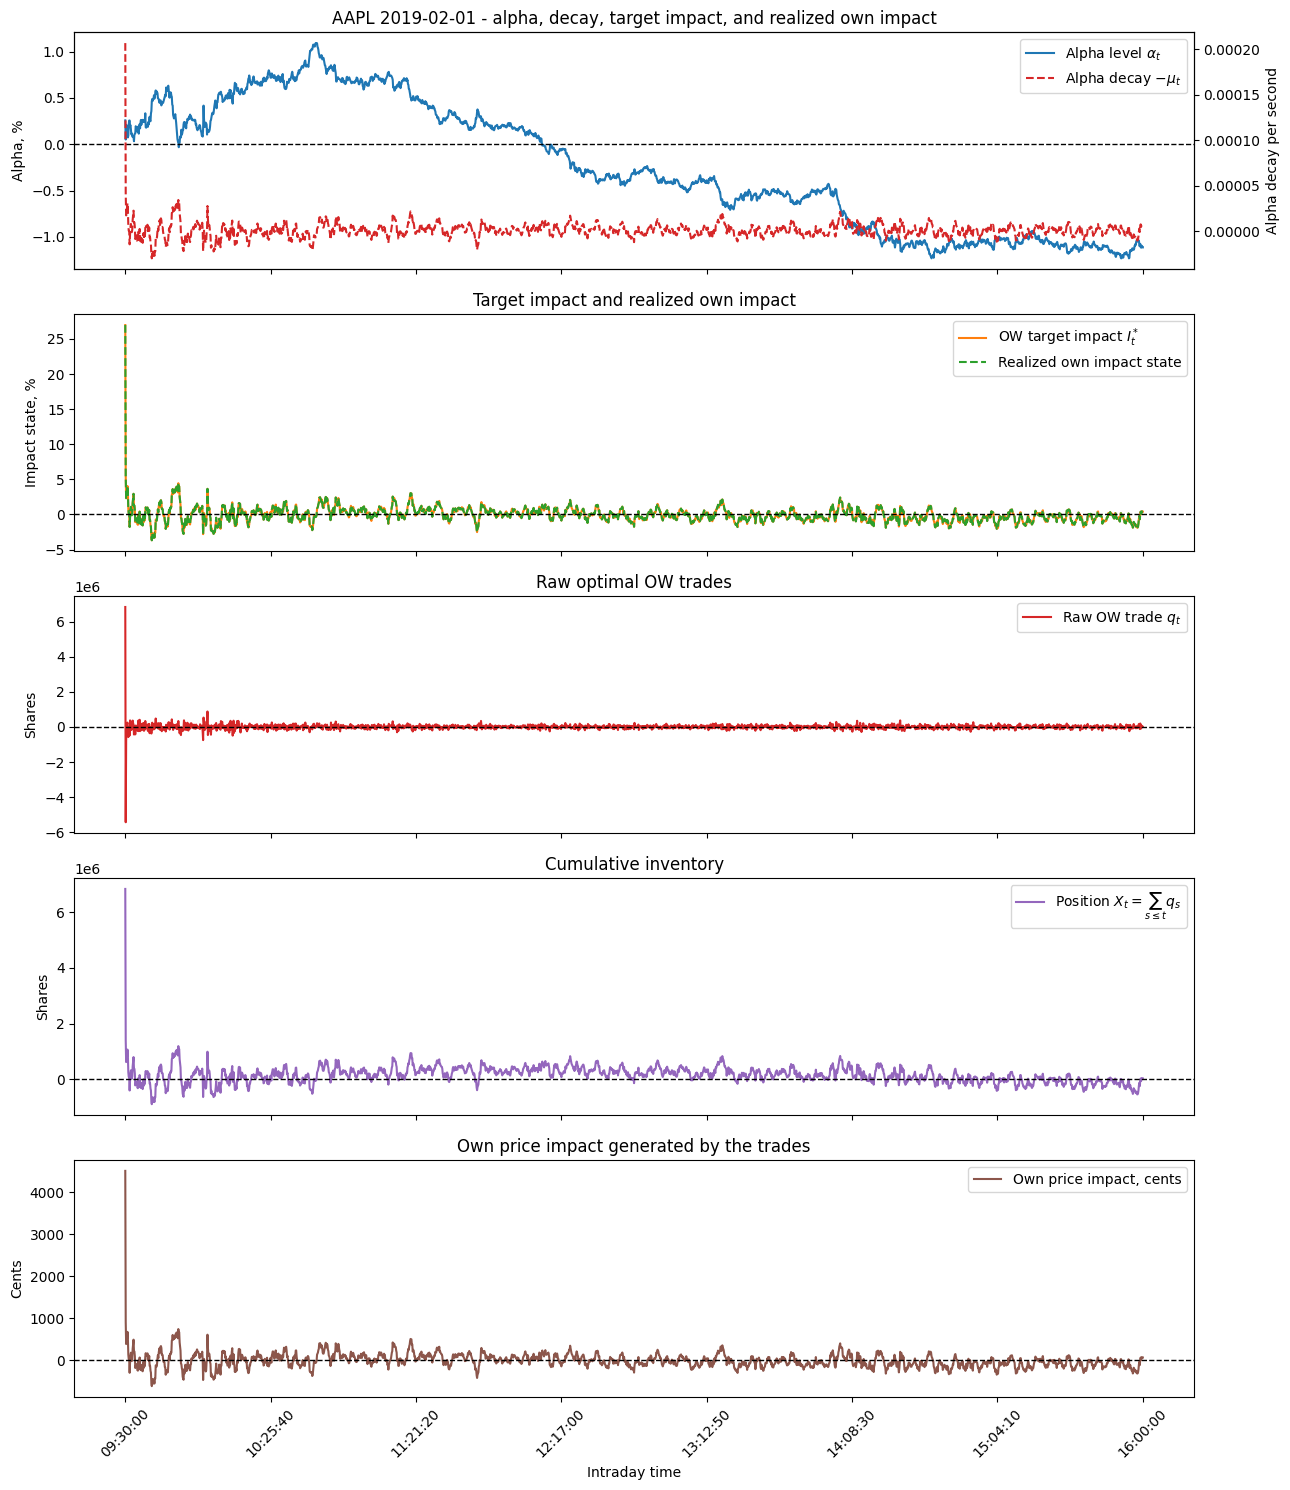

,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,avg_price,traded_notional,model_type,stock,date,lambda_hat,ADV,sigma,half_life_seconds
intraday_only,-344816141.234051,343320596.067553,45.01885,30284.536515,192048552.830252,30284.536515,167.348726,32139080658.037022,ow,AAPL,2019-02-01,407.392206,2968462.809524,0.000288,1800.0


In [ ]:
stock = "AAPL"

if stock in test_px_df.index.get_level_values("stock"):
    date = test_px_df.loc[stock].index[0]
else:
    stock, date = test_px_df.index[0]

scenario_name = "intraday_only"

# -----------------------------
# Extract alpha-to-trade objects
# -----------------------------
alpha_one = used_alpha_dfs[scenario_name].loc[(stock, date)]
alpha_decay_one = used_alpha_decay_dfs[scenario_name].loc[(stock, date)]
I_star_one = target_impact_dfs[scenario_name].loc[(stock, date)]
trades_one = strategy_trade_dfs[scenario_name].loc[(stock, date)]
position_one = trades_one.cumsum()

# -----------------------------
# Run one-stock-day backtest path
# -----------------------------
paths, summary_df = run_one_stock_day_paths_for_strategies(
    stock=stock,
    date=date,
    strategy_trade_dfs={scenario_name: strategy_trade_dfs[scenario_name]},
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

path = paths[scenario_name]

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(alpha_one))
tick_positions = np.linspace(0, len(alpha_one) - 1, 8, dtype=int)
tick_labels = alpha_one.index[tick_positions]

fig, axes = plt.subplots(5, 1, figsize=(13, 15), sharex=True)

# -----------------------------
# 1. Alpha level and alpha decay
# -----------------------------
ax1 = axes[0]

line1 = ax1.plot(
    x,
    100 * alpha_one.values,
    color="tab:blue",
    label=r"Alpha level $\alpha_t$",
)

ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_ylabel("Alpha, %")
ax1.set_title(f"{stock} {date} - alpha, decay, target impact, and realized own impact")

ax1b = ax1.twinx()
line2 = ax1b.plot(
    x,
    alpha_decay_one.values,
    color="tab:red",
    linestyle="--",
    label=r"Alpha decay $-\mu_t$",
)
ax1b.set_ylabel("Alpha decay per second")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

# -----------------------------
# 2. Target impact and realized impact state
# -----------------------------
axes[1].plot(
    x,
    100 * I_star_one.values,
    color="tab:orange",
    label=r"OW target impact $I_t^*$",
)

axes[1].plot(
    x,
    100 * path["impact_state"].values,
    color="tab:green",
    linestyle="--",
    label="Realized own impact state",
)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Impact state, %")
axes[1].set_title("Target impact and realized own impact")
axes[1].legend()

# -----------------------------
# 3. Actual trades q_t
# -----------------------------
axes[2].plot(
    x,
    trades_one.values,
    color="tab:red",
    label=r"Raw OW trade $q_t$",
)

axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("Shares")
axes[2].set_title("Raw optimal OW trades")
axes[2].legend()

# -----------------------------
# 4. Cumulative position
# -----------------------------
axes[3].plot(
    x,
    position_one.values,
    color="tab:purple",
    label=r"Position $X_t = \sum_{s \leq t} q_s$",
)

axes[3].axhline(0, color="black", linestyle="--", linewidth=1)
axes[3].set_ylabel("Shares")
axes[3].set_title("Cumulative inventory")
axes[3].legend()

# -----------------------------
# 5. Own impact in price units
# -----------------------------
axes[4].plot(
    x,
    100 * path["impact_in_price"].values,
    color="tab:brown",
    label="Own price impact, cents",
)

axes[4].axhline(0, color="black", linestyle="--", linewidth=1)
axes[4].set_ylabel("Cents")
axes[4].set_title("Own price impact generated by the trades")
axes[4].legend()

# -----------------------------
# Shared x-axis
# -----------------------------
axes[4].set_xticks(tick_positions)
axes[4].set_xticklabels(tick_labels, rotation=45)
axes[4].set_xlabel("Intraday time")

plt.tight_layout()
plt.show()

display(summary_df)